<img align="left" src = https://project.lsst.org/sites/default/files/Rubin-O-Logo_0.png width=250 style="padding: 10px"> 
<br>
<b>Prompt processing analysis (03/02/2026)</b> <br>
Contact author: Bruno Sanchez<br>
Last verified to run: 03 February 2026<br>
LSST Science Piplines version: w_2026_04<br>
Run at USDF on repo embargo

# 1. Main package imports

In [94]:
import os
import importlib
import pprint

import matplotlib.pyplot as plt
%matplotlib inline

import math
import numpy as np
import pandas as pd
import scipy
import astropy.units as u
from astropy.coordinates import SkyCoord

In [2]:
np.set_printoptions(precision=3)

In [3]:
import lsst.afw.image as afwImage
import lsst.afw.display as afwDisplay
import lsst.geom
import lsst.afw.geom as afwGeom

import lsst.daf.butler as dafButler
import lsst.pipe.base

In [4]:
from lsst.analysis.ap import apdb
from lsst.analysis.ap import nb_utils
from astropy.table import Table, hstack, vstack

In [6]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [7]:
afwDisplay.setDefaultBackend("matplotlib")

## Load previous run datasheets

In [14]:
import os
os.chdir('./u/DM-53803')

In [15]:
daytime_run = pd.read_csv('daytime_rerun_processingIds.csv')

In [16]:
prompt_run = pd.read_csv('prompt_rerun_processingIds.csv')

In [18]:
prompt_run

,Unnamed: 0,instrument,detector,visit,band,day_obs,physical_filter,computeReliability:computeReliability:__version__,computeReliability:computeReliability:nodeName,computeReliability:computeReliability:runStartUtc,...,computeReliability:computeReliability:deltaTimeCpuTime,computeReliability:computeReliability:deltaTimeUserTime,computeReliability:computeReliability:deltaTimeSystemTime,collection,date,computeReliability:quantum:butler_metrics:time_in_ingest,computeReliability:quantum:butler_metrics:n_ingest,quantum:quantum:butler_metrics:time_in_ingest,quantum:quantum:butler_metrics:n_ingest,n_chunks
0,11,LSSTCam,112,2026012800097,g,20260128,g_6,1.0,prompt-keda-lsstcam-mpjgw-ljvnt,2026-01-29T01:53:24.008610+00:00,...,9.755554,8.569421,1.185831,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,1.0
1,26,LSSTCam,50,2026012800097,g,20260128,g_6,1.0,prompt-keda-lsstcam-bwwf5-x26s6,2026-01-29T01:53:15.834037+00:00,...,9.815232,8.645919,1.169100,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,1.0
2,46,LSSTCam,46,2026012800092,g,20260128,g_6,1.0,prompt-keda-lsstcam-c5km5-5gg8c,2026-01-29T01:45:02.211604+00:00,...,9.825626,8.693069,1.132378,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,1.0
3,135,LSSTCam,96,2026012800092,g,20260128,g_6,1.0,prompt-keda-lsstcam-5twnt-bp8xc,2026-01-29T01:45:14.388277+00:00,...,10.100236,8.811662,1.288367,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,1.0
4,161,LSSTCam,112,2026012800092,g,20260128,g_6,1.0,prompt-keda-lsstcam-s5b4m-zs7kk,2026-01-29T01:45:18.805796+00:00,...,9.895243,8.778126,1.116730,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,1448,LSSTCam,96,2026012800099,i,20260128,i_39,1.0,prompt-keda-lsstcam-p4tvk-67pb4,2026-01-29T01:58:23.356119+00:00,...,15.045140,13.478250,1.566692,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,2.0
76,1452,LSSTCam,129,2026012800099,i,20260128,i_39,1.0,prompt-keda-lsstcam-xvv5g-76mtg,2026-01-29T01:58:18.149313+00:00,...,14.417597,12.809920,1.607513,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,2.0
77,1461,LSSTCam,50,2026012800099,i,20260128,i_39,1.0,prompt-keda-lsstcam-fsc6p-8nhjp,2026-01-29T01:58:19.518958+00:00,...,15.208513,13.654964,1.553429,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,2.0
78,1499,LSSTCam,57,2026012800099,i,20260128,i_39,1.0,prompt-keda-lsstcam-d42wb-sk257,2026-01-29T01:58:37.638176+00:00,...,14.880731,13.138375,1.742266,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,2.0


### Some functions for loading and processing

In [30]:
from copy import copy
from lsst.pipe.base._task_metadata import TaskMetadata

def unpack_nested_dict(d, parent_key='', result=None):
    if result is None:
        result = {}
    if not isinstance(d, (dict, TaskMetadata)): 
        new_key = f"{parent_key}" if parent_key else 'sValue'
        result[new_key] = d
        return result
    for key, value in d.items():
        # Create a new key path
        new_key = f"{parent_key}:{key}" if parent_key else key

        if isinstance(value, (dict, TaskMetadata)) :
            # Recursive call to process nested dictionaries
            unpack_nested_dict(dict(value), new_key, result)
        else:
            # Store the concatenated key path and value in the result dictionary
            result[new_key] = value[0] if isinstance(value, list) else value

    return result

In [31]:
def get_delta_proc_times(df, basekey):
    time_colnames = ['Utc', 'CpuTime', 'UserTime', 'SystemTime']
    df_new = df.copy()

    for atime in time_colnames:
        if atime == 'Utc':
            start_time = pd.to_datetime(df[basekey+':runStart'+atime])
            end_time = pd.to_datetime(df[basekey+':runEnd'+atime])
            delta_time = end_time - start_time
            df_new[basekey+':runStart'+atime+'_dt'] = start_time
            df_new[basekey+':runEnd'+atime+'_dt'] = end_time
            df_new[basekey+':deltaTime'+atime+'_dt'] = delta_time
            df_new[basekey+':deltaTime'+atime+'_dt_secs'] = delta_time.dt.total_seconds()
        else:
            start_time = df[basekey+':runStart'+atime]
            end_time = df[basekey+':runEnd'+atime]
            df_new[basekey+':deltaTime'+atime] = end_time - start_time
    
    return df_new

In [32]:
def count_diaSources(visit, detector):
    """Count diaSources and compute mean reliability for a given visit and detector."""
    try:
        candidate = butler.get("dia_source_detector", visit=visit, detector=detector)
        # standard = butler.get("dia_source_detector", visit=visit, detector=detector)
        # dia_source = butler.get("dia_source_apdb", visit=visit, detector=detector)
        # print(f"{visit}: {len(candidate)} | {len(dia_source)}")
        return visit, detector, len(candidate), np.mean(candidate['reliability']),  #len(dia_source), np.mean(dia_source['reliability'])
    except dafButler.DatasetNotFoundError:
        return visit, detector, np.nan, np.nan, # np.nan, np.nan
        # print(f"{visit} detector {detector} not found")

In [33]:
def dump_logs_to_file(metadata_df, butler, filename='logs_plain_text.log', task='computeReliability'):
    with open(filename, 'w') as f:
        for rowid, rowdata in metadata_df.iterrows():
            row_log = butler.get(f'{task}_log', visit=rowdata['visit'], detector=rowdata['detector'])
            for log in row_log:
                f.write(log.message + '\n')
    return filename

In [95]:
def load_timings_from_logs(meta_df_2, butler):
    nsrcs = np.zeros(len(meta_df_2), dtype=int)
    tmplt_read_timing = np.zeros(len(meta_df_2), dtype=float)
    science_read_timing = np.zeros(len(meta_df_2), dtype=float)
    diff_read_timing = np.zeros(len(meta_df_2), dtype=float)
    for rowid, rowdata in meta_df_2.iterrows():
        # print(rowid)
        # print(rowdata['visit'], rowdata['detector'])
        row_log = butler.get('computeReliability_log', visit=rowdata['visit'], detector=rowdata['detector'])
        for log in row_log:
            if 'Scored' in log.message:
                n_stamps = int(log.message.split()[1])
            if 'Reading from location' in log.message and 'FitsExposureFormatter' in log.message:
                # reading data in image format
                if 'template_detector' in log.message:
                    # reading template
                    tmplt_read_time = float(log.message.split()[-2])
                    tmplt_read_timing[rowid] = tmplt_read_time
                if 'preliminary_visit_image' in log.message:
                    # reading science image
                    science_read_time = float(log.message.split()[-2])
                    science_read_timing[rowid] = science_read_time
                if 'difference_image' in log.message:
                    # reading difference image
                    diff_read_time = float(log.message.split()[-2])
                    diff_read_timing[rowid] = diff_read_time

        nsrcs[rowid] = n_stamps
        
    meta_df_2['n_stamps_scored'] = nsrcs
    meta_df_2['tmplt_read_timing'] = tmplt_read_timing
    meta_df_2['science_read_timing'] = science_read_timing
    meta_df_2['diff_read_timing'] = diff_read_timing

    return meta_df_2

In [35]:
def load_meta_and_logs(drefs, butler=butler):
    datarows = []
    for aref in drefs:
        datarow = dict(aref.dataId.to_simple())['dataId']
        try:
            rb_meta = butler.get(aref)
            for kmetric, vmetric in rb_meta.items():
                datarow.update(unpack_nested_dict(rb_meta, parent_key=kmetric))
            rb_log = butler.get('computeReliability_log', dataId=aref.dataId)
            for aline in rb_log:
                if 'Scored ' in aline.message:
                    n_stamps = int(aline.message.split()[1])
                    break
            datarow['n_stamps_scored'] = n_stamps
            datarows.append(datarow)
        except:
            continue
    metadata_df = pd.DataFrame(datarows)
    return metadata_df

In [36]:
def parse_prompt_collection(collection_name):
    butler = dafButler.Butler('/repo/embargo', instrument='LSSTCam', collections=collection_name)
    drefs = butler.registry.queryDatasets("computeReliability_metadata", collections=collection_name)
    print("Amount of data refs in the collection for dia_source_detector:", len(list(drefs)))
    meta_df = load_meta_and_logs(drefs, butler=butler)
    meta_df = get_delta_proc_times(meta_df, 'computeReliability:computeReliability')
    return meta_df

# Get a butler

We will grabbing data from the 

In [106]:
repo = 's3://rubin-pp-dev-users/central_repo_2'

In [107]:
skymap = "lsst_cells_v1"
butler = dafButler.Butler(repo, instrument='LSSTCam', skymap='lsst_cells_v1')
skyMap = butler.get("skyMap", collections="skymaps", skymap="lsst_cells_v1")

In [108]:
def find_datasets(butler, dataset, collectionPattern="*"):
    infos = {}
    for info in butler.collections.query_info(collectionPattern, include_summary=True):
        if dataset in info.dataset_types:
            print(info.name)
            infos[info.name] = info
    return infos

In [109]:
camera = butler.get("camera", instrument='LSSTCam', collections=["LSSTCam/calib", "LSSTCam/defaults"] )

In [110]:
infos = find_datasets(butler, "difference_image", collectionPattern="LSSTCam/prompt/output-2026-02-09*") #/prompt*")

LSSTCam/prompt/output-2026-02-09/ApPipe/pipelines-c82627e-config-0dc223f
LSSTCam/prompt/output-2026-02-09


In [111]:
infoprompt = infos['LSSTCam/prompt/output-2026-02-09/ApPipe/pipelines-c82627e-config-0dc223f']

In [112]:
# date = "2026-01-27"  # example date of the prompt processing
# collection_base = "LSSTCam/prompt/output-"+date
collection_base = 'LSSTCam/prompt/output-2026-02-09/ApPipe/pipelines-c82627e-config-0dc223f'
butler.registry.queryCollections(collection_base)

['LSSTCam/prompt/output-2026-02-09/ApPipe/pipelines-c82627e-config-0dc223f']

In [113]:
butler = dafButler.Butler(
    repo, instrument='LSSTCam', skymap='lsst_cells_v1', collections=collection_base
)

In [114]:
drefs = butler.registry.queryDatasets(
    "computeReliability_metadata", 
    collections=collection_base
)

In [115]:
print("Amount of data refs in the collection for dia_source_detector:", len(list(drefs)))

Amount of data refs in the collection for dia_source_detector: 4847


In [47]:
visits = []
detectors = []
bands = []
for ref in drefs:
    dataId = ref.dataId
    visits.append(dataId['visit'])
    detectors.append(dataId['detector'])
    bands.append(dataId['band'])
visits = set(visits)
detectors = set(detectors)
bands = set(bands)

In [48]:
# Show up how many visits and unique detectors and bands are present
print(len(visits), len(detectors), len(bands))
print(visits, bands)

27 188 2
{2026020920001, 2026020920002, 2026020920003, 2026020920004, 2026020920005, 2026020920006, 2026020920007, 2026020920008, 2026020920009, 2026020920010, 2026020920011, 2026020920012, 2026020920013, 2026020920014, 2026020920015, 2026020920016, 2026020920017, 2026020920018, 2026020920019, 2026020920020, 2026020920021, 2026020920022, 2026020920023, 2026020920024, 2026020920025, 2026020920026, 2026020920027} {'g', 'i'}


In [49]:
ref

DatasetRef(DatasetType('computeReliability_metadata', {band, instrument, day_obs, detector, physical_filter, visit}, TaskMetadata), {instrument: 'LSSTCam', detector: 163, visit: 2026020920027, band: 'i', day_obs: 20260209, physical_filter: 'i_39'}, run='LSSTCam/prompt/output-2026-02-09/ApPipe/pipelines-c82627e-config-0dc223f', id=019c4526-be1c-7e9f-8366-c7803b2241e1)

In [50]:
ref.dataId

{instrument: 'LSSTCam', detector: 163, visit: 2026020920027, band: 'i', day_obs: 20260209, physical_filter: 'i_39'}

In [96]:
datarows = []
for aref in drefs:
    datarow = dict(aref.dataId.to_simple())['dataId']
    try:
        rb_meta = butler.get(aref)
        for kmetric, vmetric in rb_meta.items():
            datarow.update(unpack_nested_dict(rb_meta, parent_key=kmetric))
        datarows.append(datarow)
    except:
        continue
metadata_df = pd.DataFrame(datarows)

In [97]:
metadata_df

,instrument,detector,visit,band,day_obs,physical_filter,computeReliability:computeReliability:__version__,computeReliability:computeReliability:nodeName,computeReliability:computeReliability:runStartUtc,computeReliability:computeReliability:runStartCpuTime,...,quantum:quantum:endBlockOutputs,quantum:quantum:endVoluntaryContextSwitches,quantum:quantum:endInvoluntaryContextSwitches,quantum:quantum:outputs,quantum:quantum:butler_metrics:time_in_put,quantum:quantum:butler_metrics:time_in_get,quantum:quantum:butler_metrics:time_in_ingest,quantum:quantum:butler_metrics:n_get,quantum:quantum:butler_metrics:n_put,quantum:quantum:butler_metrics:n_ingest
0,LSSTCam,142,2026020920013,i,20260209,i_39,1,prompt-keda-lsstcam-x7c8v-h46g4,2026-02-09T23:22:10.442536+00:00,726.899563,...,14042592,589076,3278749,019c44b4-a6df-7223-a015-3864ee9b3add,0.103797,4.884676,0.0,5,1,0
1,LSSTCam,186,2026020920013,i,20260209,i_39,1,prompt-keda-lsstcam-6h4nv-hf6gd,2026-02-09T23:22:15.253444+00:00,728.103429,...,14216672,598245,3592150,019c44b4-d1f8-79de-a6aa-4fc453e921ea,0.104361,2.666682,0.0,5,1,0
2,LSSTCam,178,2026020920013,i,20260209,i_39,1,prompt-keda-lsstcam-cm98c-qzm2r,2026-02-09T23:22:15.035577+00:00,778.450476,...,16240448,682411,3027585,019c44b4-c710-737e-aff9-0bdfec69d9d5,0.104711,3.924016,0.0,5,1,0
3,LSSTCam,174,2026020920013,i,20260209,i_39,1,prompt-keda-lsstcam-9r5mx-z9zf6,2026-02-09T23:22:14.651081+00:00,781.283554,...,14946640,640895,2520911,019c44b4-c654-7d0e-a5e9-07ad8012adbd,0.017034,4.492284,0.0,5,1,0
4,LSSTCam,114,2026020920013,i,20260209,i_39,1,prompt-keda-lsstcam-7m7bz-rjp7k,2026-02-09T23:22:12.739008+00:00,728.515007,...,13413152,548932,2489494,019c44b4-9762-7045-9f03-8b677ae4cd5b,0.208179,5.721747,0.0,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4842,LSSTCam,137,2026020920027,i,20260209,i_39,1,prompt-keda-lsstcam-z2bvs-kpx4t,2026-02-10T01:26:54.585324+00:00,588.894474,...,12592848,529258,2128983,019c4526-af57-7c85-ba8b-38d88864c3b6,0.106017,6.716716,0.0,5,1,0
4843,LSSTCam,162,2026020920027,i,20260209,i_39,1,prompt-keda-lsstcam-vh4bn-zcjgg,2026-02-10T01:26:58.469711+00:00,429.474682,...,9072864,318973,1630842,019c4526-c1a8-7668-9c77-433ea823d618,0.107613,3.520153,0.0,5,1,0
4844,LSSTCam,160,2026020920027,i,20260209,i_39,1,prompt-keda-lsstcam-9gkrf-plkkc,2026-02-10T01:26:56.329593+00:00,525.029473,...,10397304,430808,2167035,019c4526-c3af-7c4a-89f9-9737f431af9e,0.014757,6.561588,0.0,5,1,0
4845,LSSTCam,166,2026020920027,i,20260209,i_39,1,prompt-keda-lsstcam-smbtb-w24sg,2026-02-10T01:27:09.560510+00:00,592.398333,...,11687176,479009,1939724,019c4526-c3b6-7095-8f3e-92f958655e69,0.015692,4.309699,0.0,5,1,0


In [98]:
# metadata_df['computeReliability:quantum:startUtc']
metadata_df['computeReliability:quantum:startUtc_dt'] = pd.to_datetime(metadata_df['computeReliability:quantum:startUtc'])

In [99]:
metadata_df[[
    'computeReliability:computeReliability:runStartUtc',
    'computeReliability:computeReliability:runStartCpuTime',
    'computeReliability:computeReliability:runStartUserTime',
    'computeReliability:computeReliability:runStartSystemTime',
    'computeReliability:computeReliability:runEndUtc',
    'computeReliability:computeReliability:runEndCpuTime',
    'computeReliability:computeReliability:runEndUserTime',
    'computeReliability:computeReliability:runEndSystemTime',
]]

,computeReliability:computeReliability:runStartUtc,computeReliability:computeReliability:runStartCpuTime,computeReliability:computeReliability:runStartUserTime,computeReliability:computeReliability:runStartSystemTime,computeReliability:computeReliability:runEndUtc,computeReliability:computeReliability:runEndCpuTime,computeReliability:computeReliability:runEndUserTime,computeReliability:computeReliability:runEndSystemTime
0,2026-02-09T23:22:10.442536+00:00,726.899563,664.182444,62.717097,2026-02-09T23:22:23.313676+00:00,739.802994,675.007152,64.795730
1,2026-02-09T23:22:15.253444+00:00,728.103429,669.307329,58.796078,2026-02-09T23:22:27.118550+00:00,740.028448,679.331149,60.697200
2,2026-02-09T23:22:15.035577+00:00,778.450476,725.773160,52.677289,2026-02-09T23:22:27.847160+00:00,791.312561,736.912204,54.400253
3,2026-02-09T23:22:14.651081+00:00,781.283554,718.469815,62.813716,2026-02-09T23:22:25.857433+00:00,792.492072,728.099756,64.392250
4,2026-02-09T23:22:12.739008+00:00,728.515007,680.037035,48.477949,2026-02-09T23:22:24.841666+00:00,740.689692,690.433267,50.256169
...,...,...,...,...,...,...,...,...
4842,2026-02-10T01:26:54.585324+00:00,588.894474,551.657204,37.237247,2026-02-10T01:27:07.554489+00:00,601.927153,562.949453,38.977563
4843,2026-02-10T01:26:58.469711+00:00,429.474682,400.153888,29.320774,2026-02-10T01:27:11.532420+00:00,442.619896,411.448572,31.171196
4844,2026-02-10T01:26:56.329593+00:00,525.029473,490.055858,34.973586,2026-02-10T01:27:09.328456+00:00,538.057244,501.183856,36.873317
4845,2026-02-10T01:27:09.560510+00:00,592.398333,556.405042,35.993270,2026-02-10T01:27:21.928547+00:00,604.807047,567.197929,37.609036


In [100]:
metadata_df_2 = get_delta_proc_times(metadata_df, 'computeReliability:computeReliability')

In [101]:
deltaCols = [col for col in metadata_df_2.columns if 'deltaTime' in col]

In [102]:
metadata_df_2[deltaCols]

,computeReliability:computeReliability:deltaTimeUtc_dt,computeReliability:computeReliability:deltaTimeUtc_dt_secs,computeReliability:computeReliability:deltaTimeCpuTime,computeReliability:computeReliability:deltaTimeUserTime,computeReliability:computeReliability:deltaTimeSystemTime
0,0 days 00:00:12.871140,12.871140,12.903431,10.824708,2.078633
1,0 days 00:00:11.865106,11.865106,11.925019,10.023820,1.901122
2,0 days 00:00:12.811583,12.811583,12.862085,11.139044,1.722964
3,0 days 00:00:11.206352,11.206352,11.208518,9.629941,1.578534
4,0 days 00:00:12.102658,12.102658,12.174685,10.396232,1.778220
...,...,...,...,...,...
4842,0 days 00:00:12.969165,12.969165,13.032679,11.292249,1.740316
4843,0 days 00:00:13.062709,13.062709,13.145214,11.294684,1.850422
4844,0 days 00:00:12.998863,12.998863,13.027771,11.127998,1.899731
4845,0 days 00:00:12.368037,12.368037,12.408714,10.792887,1.615766


Text(0.5, 0, 'DeltaTime')

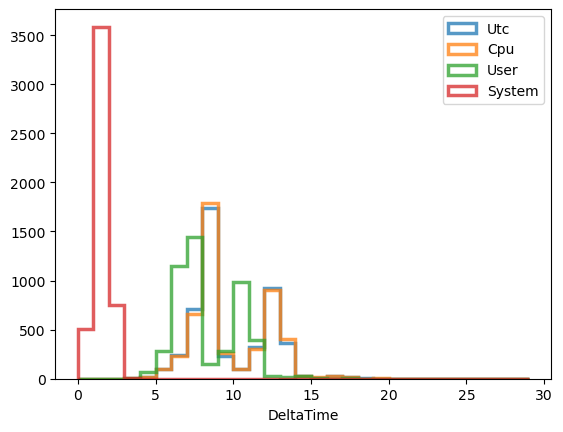

In [103]:
xbins = np.arange(0, 30, 1)
hist_config = {'bins': xbins, 'histtype': 'step', 'lw': 2.5, 'alpha': 0.75}
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeUtc_dt_secs'], 
         label='Utc', **hist_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeCpuTime'],
         label='Cpu', **hist_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeUserTime'],
         label='User', **hist_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeSystemTime'],
         label='System', **hist_config)
plt.legend(loc='best')
plt.xlabel('DeltaTime')

In [116]:
metadata_df_2 = load_timings_from_logs(metadata_df_2, butler)

(array([ 162., 1033., 1972.,  979.,  501.,  140.,   39.,    5.,   10.,
           6.]),
 array([  3. ,  24.7,  46.4,  68.1,  89.8, 111.5, 133.2, 154.9, 176.6,
        198.3, 220. ]),
 <BarContainer object of 10 artists>)

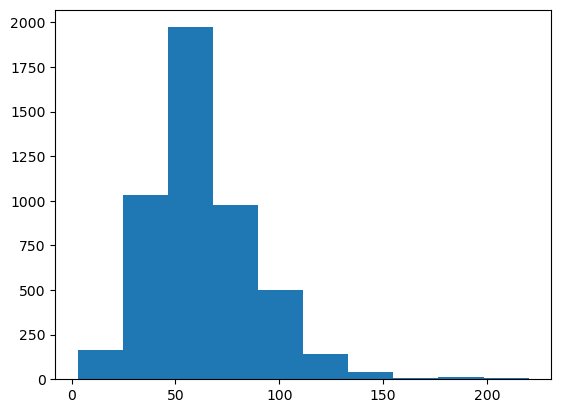

In [117]:
plt.hist(metadata_df_2['n_stamps_scored'])

Text(0, 0.5, 'Time (s)')

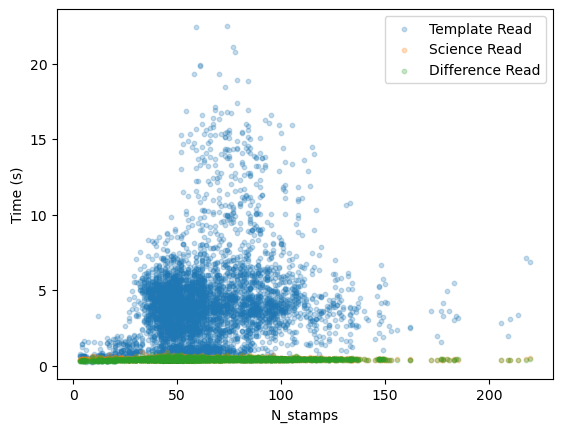

In [119]:
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['tmplt_read_timing'], s=10, alpha=0.25, label='Template Read')
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['science_read_timing'], s=10, alpha=0.25, label='Science Read')
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['diff_read_timing'], s=10, alpha=0.25, label='Difference Read')
# plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeSystemTime'], s=10, alpha=0.5, label='System')
# plt.ylim(0, 2)
# plt.gca().set_yscale('log')
plt.legend(loc='best')
plt.xlabel('N_stamps')
plt.ylabel('Time (s)')

Text(0, 0.5, 'Template Read Timing (s)')

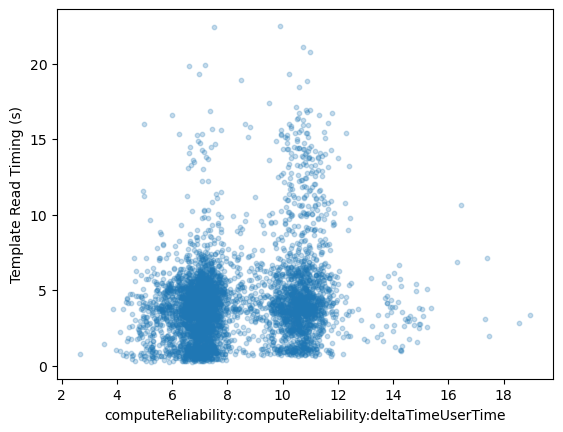

In [120]:
plt.scatter(metadata_df_2['computeReliability:computeReliability:deltaTimeUserTime'], 
            metadata_df_2['tmplt_read_timing'], s=10, alpha=0.25, label='Template Read')
plt.xlabel('computeReliability:computeReliability:deltaTimeUserTime')
plt.ylabel('Template Read Timing (s)')

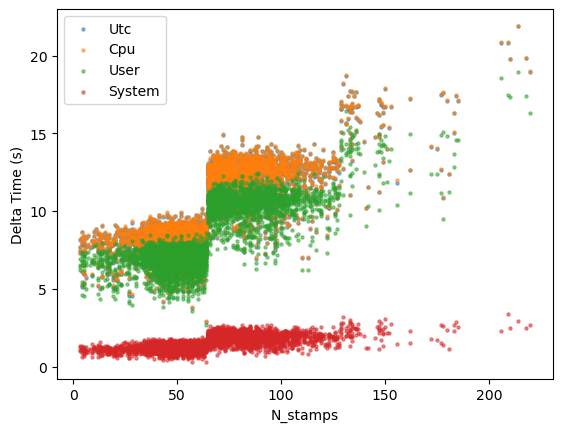

In [121]:
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeUtc_dt_secs'], s=5, alpha=0.5, label='Utc')
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeCpuTime'], s=5, alpha=0.5, label='Cpu')
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeUserTime'], s=5, alpha=0.5, label='User')
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeSystemTime'], s=5, alpha=0.5, label='System')
plt.xlabel('N_stamps')
plt.ylabel('Delta Time (s)')
plt.legend(loc='best')

Text(0.5, 0, 'DeltaTime/N_stamps')

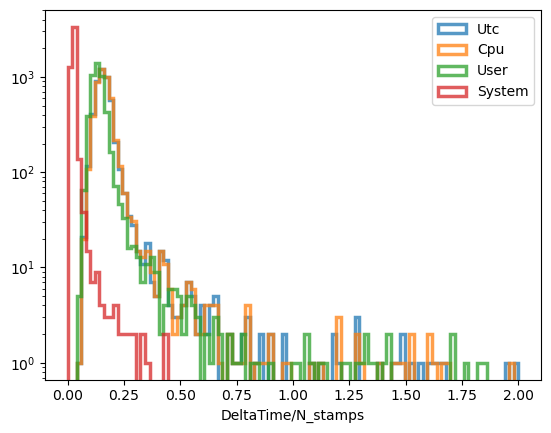

In [122]:
xbins = np.linspace(0, 2, 100)
hist2_config = {'bins': xbins, 'histtype': 'step', 'lw': 2.5, 'alpha': 0.75, 'log': True}
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeUtc_dt_secs']/metadata_df_2['n_stamps_scored'], 
         label='Utc', **hist2_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeCpuTime']/metadata_df_2['n_stamps_scored'],
         label='Cpu', **hist2_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeUserTime']/metadata_df_2['n_stamps_scored'],
         label='User', **hist2_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeSystemTime']/metadata_df_2['n_stamps_scored'],
         label='System', **hist2_config)
plt.legend(loc='best')
plt.xlabel('DeltaTime/N_stamps')

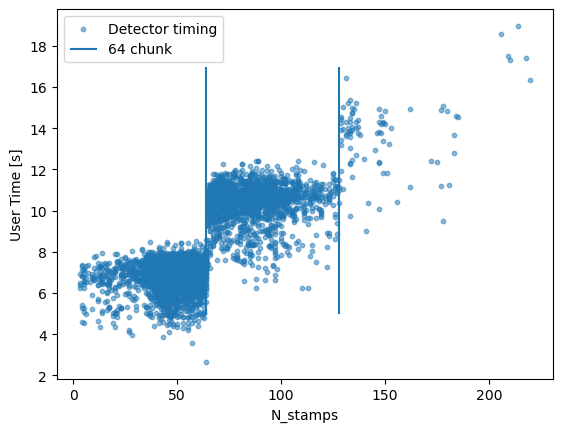

In [123]:
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeUserTime'], s=10, alpha=0.5, label='Detector timing')
plt.vlines(x=[64, 128], ymin=5, ymax=17, label='64 chunk')
plt.xlabel("N_stamps")
plt.ylabel("User Time [s]")
plt.legend(loc='best')

In [124]:
""" mapping of visit to new visits
2026020920015  <--- 2026012800087
2026020920016  <--- 2026012800088
2026020920017  <--- 2026012800089
2026020920018  <--- 2026012800090
2026020920019  <--- 2026012800091
2026020920020  <--- 2026012800092
2026020920021  <--- 2026012800097
2026020920022  <--- 2026012800098
2026020920023  <--- 2026012800099
2026020920024  <--- 2026012800101
2026020920025  <--- 2026012800102
2026020920026  <--- 2026012800103
2026020920027  <--- 2026012800104
"""

' mapping of visit to new visits\n2026020920015  <--- 2026012800087\n2026020920016  <--- 2026012800088\n2026020920017  <--- 2026012800089\n2026020920018  <--- 2026012800090\n2026020920019  <--- 2026012800091\n2026020920020  <--- 2026012800092\n2026020920021  <--- 2026012800097\n2026020920022  <--- 2026012800098\n2026020920023  <--- 2026012800099\n2026020920024  <--- 2026012800101\n2026020920025  <--- 2026012800102\n2026020920026  <--- 2026012800103\n2026020920027  <--- 2026012800104\n'

In [125]:
# define new column with the mapped visits
visit_mapping = {
    2026020920015: 2026012800087,
    2026020920016: 2026012800088,
    2026020920017: 2026012800089,
    2026020920018: 2026012800090,
    2026020920019: 2026012800091,
    2026020920020: 2026012800092,
    2026020920021: 2026012800097,
    2026020920022: 2026012800098,
    2026020920023: 2026012800099,
    2026020920024: 2026012800101,
    2026020920025: 2026012800102,
    2026020920026: 2026012800103,
    2026020920027: 2026012800104
}
metadata_df_2['mapped_visit'] = metadata_df_2['visit'].map(visit_mapping)

## Compare original runs vs PPDev

In [126]:
prompt_rerun = pd.merge(metadata_df_2, prompt_run, left_on=['mapped_visit', 'detector'], right_on=['visit', 'detector'], how='inner', suffixes=('_rerun', '_prompt'))

In [127]:
daytime_rerun = pd.merge(metadata_df_2, daytime_run, left_on=['mapped_visit', 'detector'], right_on=['visit', 'detector'], how='inner', suffixes=('_rerun', '_daytime'))

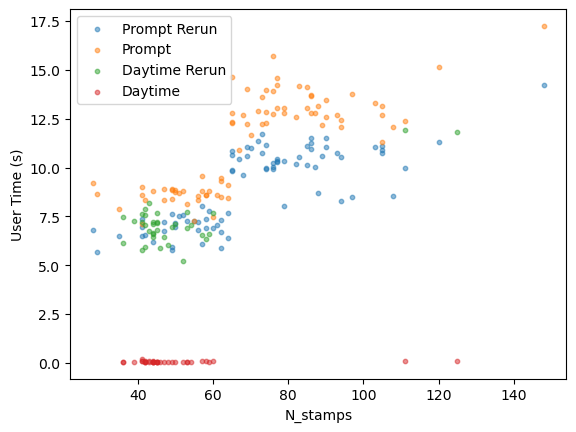

In [128]:
# scatter of user time vs n_stamps for the prompt rerun and daytime rerun, with different colors for the two runs
plt.scatter(prompt_rerun['n_stamps_scored_rerun'], prompt_rerun['computeReliability:computeReliability:deltaTimeUserTime_rerun'], s=10, alpha=0.5, label='Prompt Rerun')
plt.scatter(prompt_rerun['n_stamps_scored_rerun'], prompt_rerun['computeReliability:computeReliability:deltaTimeUserTime_prompt'], s=10, alpha=0.5, label='Prompt')
plt.scatter(daytime_rerun['n_stamps_scored_rerun'], daytime_rerun['computeReliability:computeReliability:deltaTimeUserTime_rerun'], s=10, alpha=0.5, label='Daytime Rerun')
plt.scatter(daytime_rerun['n_stamps_scored_rerun'], daytime_rerun['computeReliability:computeReliability:deltaTimeUserTime_daytime'], s=10, alpha=0.5, label='Daytime')
plt.xlabel('N_stamps')
plt.ylabel('User Time (s)')
plt.legend(loc='best')

In [129]:
metadata_df_2

,instrument,detector,visit,band,day_obs,physical_filter,computeReliability:computeReliability:__version__,computeReliability:computeReliability:nodeName,computeReliability:computeReliability:runStartUtc,computeReliability:computeReliability:runStartCpuTime,...,computeReliability:computeReliability:deltaTimeUtc_dt,computeReliability:computeReliability:deltaTimeUtc_dt_secs,computeReliability:computeReliability:deltaTimeCpuTime,computeReliability:computeReliability:deltaTimeUserTime,computeReliability:computeReliability:deltaTimeSystemTime,n_stamps_scored,tmplt_read_timing,science_read_timing,diff_read_timing,mapped_visit
0,LSSTCam,142,2026020920013,i,20260209,i_39,1,prompt-keda-lsstcam-x7c8v-h46g4,2026-02-09T23:22:10.442536+00:00,726.899563,...,0 days 00:00:12.871140,12.871140,12.903431,10.824708,2.078633,87,4.0389,0.4140,0.4187,NaN
1,LSSTCam,186,2026020920013,i,20260209,i_39,1,prompt-keda-lsstcam-6h4nv-hf6gd,2026-02-09T23:22:15.253444+00:00,728.103429,...,0 days 00:00:11.865106,11.865106,11.925019,10.023820,1.901122,95,1.8508,0.4035,0.4002,NaN
2,LSSTCam,178,2026020920013,i,20260209,i_39,1,prompt-keda-lsstcam-cm98c-qzm2r,2026-02-09T23:22:15.035577+00:00,778.450476,...,0 days 00:00:12.811583,12.811583,12.862085,11.139044,1.722964,94,3.1338,0.3956,0.3827,NaN
3,LSSTCam,174,2026020920013,i,20260209,i_39,1,prompt-keda-lsstcam-9r5mx-z9zf6,2026-02-09T23:22:14.651081+00:00,781.283554,...,0 days 00:00:11.206352,11.206352,11.208518,9.629941,1.578534,95,3.6800,0.4031,0.3945,NaN
4,LSSTCam,114,2026020920013,i,20260209,i_39,1,prompt-keda-lsstcam-7m7bz-rjp7k,2026-02-09T23:22:12.739008+00:00,728.515007,...,0 days 00:00:12.102658,12.102658,12.174685,10.396232,1.778220,103,4.8887,0.4242,0.3966,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4842,LSSTCam,137,2026020920027,i,20260209,i_39,1,prompt-keda-lsstcam-z2bvs-kpx4t,2026-02-10T01:26:54.585324+00:00,588.894474,...,0 days 00:00:12.969165,12.969165,13.032679,11.292249,1.740316,82,5.8990,0.4046,0.3994,2.026013e+12
4843,LSSTCam,162,2026020920027,i,20260209,i_39,1,prompt-keda-lsstcam-vh4bn-zcjgg,2026-02-10T01:26:58.469711+00:00,429.474682,...,0 days 00:00:13.062709,13.062709,13.145214,11.294684,1.850422,123,2.6901,0.4140,0.4019,2.026013e+12
4844,LSSTCam,160,2026020920027,i,20260209,i_39,1,prompt-keda-lsstcam-9gkrf-plkkc,2026-02-10T01:26:56.329593+00:00,525.029473,...,0 days 00:00:12.998863,12.998863,13.027771,11.127998,1.899731,127,5.7019,0.4360,0.4074,2.026013e+12
4845,LSSTCam,166,2026020920027,i,20260209,i_39,1,prompt-keda-lsstcam-smbtb-w24sg,2026-02-10T01:27:09.560510+00:00,592.398333,...,0 days 00:00:12.368037,12.368037,12.408714,10.792887,1.615766,99,3.4599,0.4146,0.4231,2.026013e+12
